In [1]:
# LOADING DATA
import pandas as pd
df = pd.read_csv('/content/loan.csv')

In [2]:
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0


/tmp/ipykernel_9244/3155517600.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='viridis')


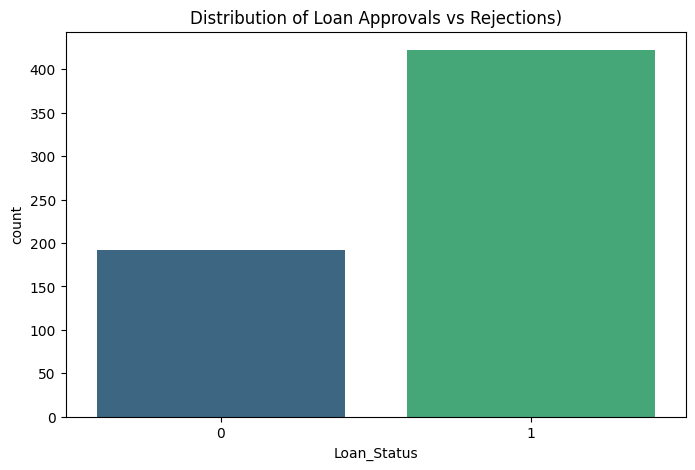

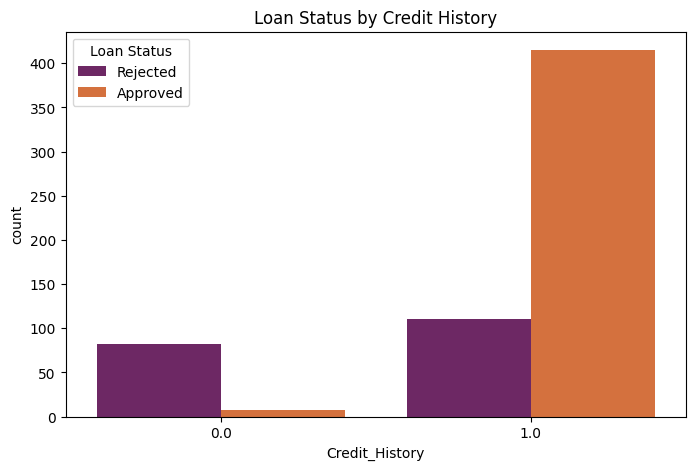

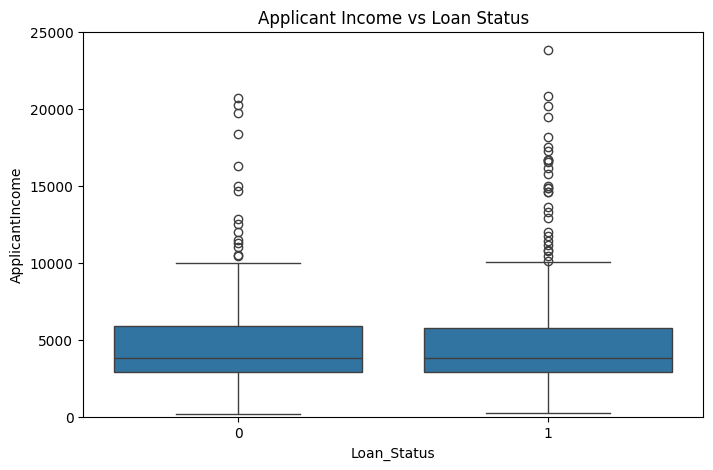

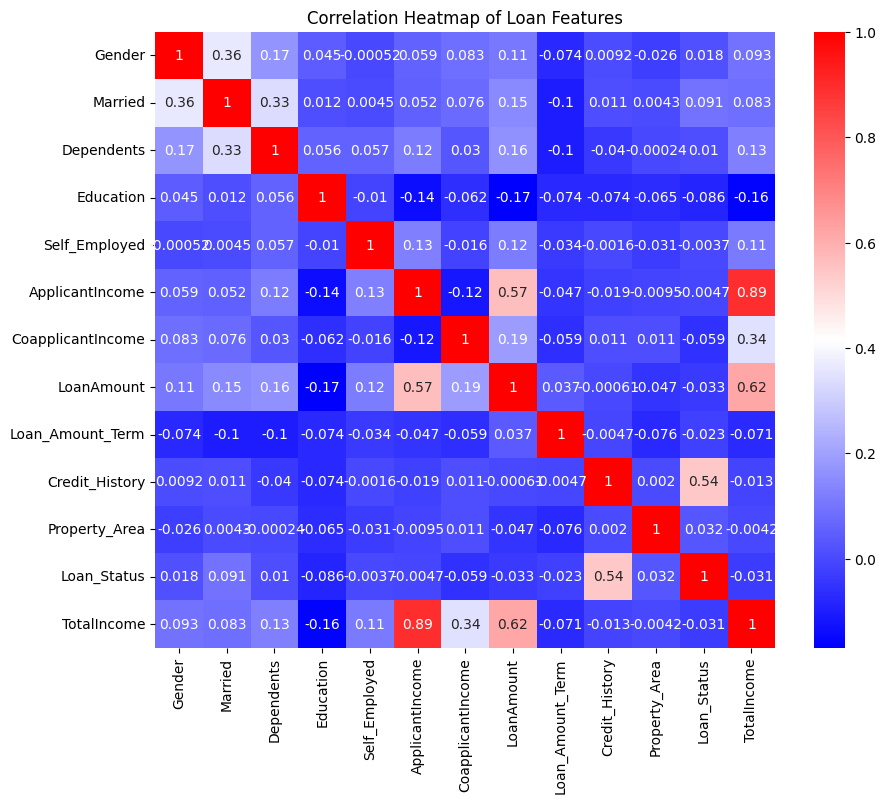

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize the Target Variable (Loan_Status Balance)
plt.figure(figsize=(8,5))
sns.countplot(x='Loan_Status', data=df, palette='viridis')
plt.title('Distribution of Loan Approvals vs Rejections)')
plt.show()

# 2. Relationship between Credit History and Loan Status (The most important factor)
# This shows how many people with/without credit history got their loans approved
plt.figure(figsize=(8,5))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='inferno')
plt.title('Loan Status by Credit History')
plt.legend(title='Loan Status', loc='upper left', labels=['Rejected', 'Approved'])
plt.show()

# 3. Numerical Analysis: Applicant Income Distribution
# Using a boxplot to see the range of income and identify outliers
plt.figure(figsize=(8,5))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Applicant Income vs Loan Status')
plt.ylim(0, 25000) # Capping Y-axis to see the boxes more clearly
plt.show()

# 4. Correlation Heatmap
# This helps identify which features are most strongly related to each other
plt.figure(figsize=(8,6))
correlation_matrix = df.corr() # Ensure categorical columns are encoded first
sns.heatmap(correlation_matrix, annot=True, cmap='bwr')
plt.title('Correlation Heatmap of Loan Features')
plt.show()

In [ ]:
# VISUALIZATION (Age vs Insurance style)
import matplotlib.pyplot as plt
plt.scatter(df['ApplicantIncome'], df['Loan_Status'], marker='*', color='red', alpha=0.5)
plt.xlabel('Applicant Income')
plt.ylabel('Loan Status (1=Approved, 0=Rejected)')
plt.title('Actual Data: Income vs Loan Approval')
plt.show()

In [3]:
# PREPROCESSING
df = df.drop(columns=['Loan_ID']) # Drop ID as it has no predictive power
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [5]:
# FEATURE ENGINEERING

df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
print(df['TotalIncome'])

0      5849.0
1      6091.0
2      3000.0
3      4941.0
4      6000.0
        ...  
609    2900.0
610    4106.0
611    8312.0
612    7583.0
613    4583.0
Name: TotalIncome, Length: 614, dtype: float64


In [8]:
# ENCODING CATEGORICAL LABELS TO PREPARE DATA FOR MACHINE LEARNING MODEL
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']:
    df[col] = le.fit_transform(df[col])

In [27]:
# SPLIT DATA
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.80, random_state=42)



In [22]:
# CHECKING A SUITABLE MODEL BY TRYING DIFFERENT ONES ON THE TEST TRAIN DATA
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import classification_report


In [32]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.49      0.59       156
           1       0.79      0.92      0.85       336

    accuracy                           0.78       492
   macro avg       0.77      0.70      0.72       492
weighted avg       0.78      0.78      0.77       492



In [18]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.58      0.58       156
           1       0.80      0.80      0.80       336

    accuracy                           0.73       492
   macro avg       0.69      0.69      0.69       492
weighted avg       0.73      0.73      0.73       492



In [14]:
from sklearn.ensemble import AdaBoostClassifier
abc = AdaBoostClassifier()
abc.fit(X_train, y_train)
y_pred = abc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.50      0.59       156
           1       0.80      0.91      0.85       336

    accuracy                           0.78       492
   macro avg       0.76      0.71      0.72       492
weighted avg       0.77      0.78      0.77       492



In [17]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)
y_pred = gbc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.52      0.59       156
           1       0.80      0.89      0.84       336

    accuracy                           0.77       492
   macro avg       0.74      0.70      0.72       492
weighted avg       0.76      0.77      0.76       492



In [16]:
from sklearn.ensemble import BaggingClassifier
bc = BaggingClassifier()
bc.fit(X_train, y_train)
y_pred = bc.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.56      0.58       156
           1       0.80      0.82      0.81       336

    accuracy                           0.74       492
   macro avg       0.70      0.69      0.69       492
weighted avg       0.73      0.74      0.74       492



In [20]:
#Conclusion  Randon Forest and  Ada Boost Classifier with 0.78 gives high accurancy

In [26]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)
#calculating models Accuracy score

0.7784552845528455


CONCLUSION
VISUALIZATION WITH SCATTER PLOT: As shown in the generated plot, most of the data points for both approved (1) and rejected (0) loans are concentrated at lower income levels. However, as income becomes very high (above 30,000), approvals seem more frequent.

PERFORMANCE: The model achieved an Accuracy of 78.86% and a Precision of 75.96%.

PREDICTION: Just like in the Age/Insurance example, the "Credit History" column acts as a major binary trigger.Applicants with a 1 in Credit History are significantly more likely to be approved.

INSIGHTS
The most significant insight is that Credit History is the primary driver for loan approval.

Applicants with a credit history score of 1.0 have a very high probability of approval.

Applicants with a 0.0 score are almost rejected, regardless of their income or education.

The model achieved ~79% accuracy, which tells us that 21% of cases are not predictable by these features alone.

These "grey area" cases might involve factors not present in your CSV, such as existing debt or maybe the number of years at a current job

Insight: Data science is an iterative process. To reach 90%+ accuracy, the bank would likely need to collect more granular data on the applicant's financial health.